In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("assignment4_generative_models.ipynb")

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

%matplotlib inline

np.random.seed(42)
_ = torch.manual_seed(42)


def rel_error(x, y):
    if isinstance(x, torch.Tensor):
        x = x.detach()
    if isinstance(y, torch.Tensor):
        y = y.detach()
    return torch.max(torch.abs(x - y) / torch.clamp(torch.abs(x) + torch.abs(y), min=1e-8)).item()


def generate_tiny_shape_dataset(n_samples=256, image_size=16, seed=42, flatten=True):
    g = torch.Generator().manual_seed(seed)
    data = torch.zeros(n_samples, 1, image_size, image_size)

    for i in range(n_samples):
        img = torch.zeros(image_size, image_size)
        pattern = int(torch.randint(0, 4, (1,), generator=g).item())
        offset = int(torch.randint(1, max(2, image_size // 4), (1,), generator=g).item())

        if pattern == 0:
            size = int(torch.randint(image_size // 4, image_size // 2 + 1, (1,), generator=g).item())
            start = max(0, (image_size - size) // 2 + offset - 1)
            end = min(image_size, start + size)
            img[start:end, start:end] = 1.0
        elif pattern == 1:
            row = int(torch.randint(2, image_size - 2, (1,), generator=g).item())
            img[row - 1 : row + 1, 2 : image_size - 2] = 1.0
        elif pattern == 2:
            col = int(torch.randint(2, image_size - 2, (1,), generator=g).item())
            img[2 : image_size - 2, col - 1 : col + 1] = 1.0
        else:
            diag = torch.arange(image_size)
            img[diag, diag] = 1.0
            img[diag, torch.flip(diag, dims=[0])] = 1.0

        noise = 0.05 * torch.randn((image_size, image_size), generator=g)
        img = torch.clamp(img + noise, 0.0, 1.0)
        data[i, 0] = img

    return data.view(n_samples, -1) if flatten else data


def plot_flattened_images(batch, title, image_size=16, max_items=8):
    batch = batch.detach().cpu()
    count = min(max_items, batch.shape[0])
    plt.figure(figsize=(2 * count, 2))
    for i in range(count):
        plt.subplot(1, count, i + 1)
        plt.imshow(batch[i].view(image_size, image_size), cmap="gray", vmin=0.0, vmax=1.0)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def generate_toy_language_data(n_samples=256, seq_len=10, vocab_size=12, seed=42):
    g = torch.Generator().manual_seed(seed)
    sequences = torch.zeros(n_samples, seq_len, dtype=torch.long)

    for i in range(n_samples):
        start = int(torch.randint(1, vocab_size - 2, (1,), generator=g).item())
        rule = int(torch.randint(0, 3, (1,), generator=g).item())
        seq = [start]

        for t in range(1, seq_len):
            if rule == 0:
                nxt = 1 + ((seq[-1] - 1 + 1) % (vocab_size - 1))
            elif rule == 1:
                nxt = start if t % 2 == 0 else min(vocab_size - 1, start + 1)
            else:
                nxt = 1 + ((start - 1 + 2 * t) % (vocab_size - 1))
            seq.append(nxt)

        sequences[i] = torch.tensor(seq, dtype=torch.long)

    return sequences


class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=4, num_layers=1, max_seq_len=32, dropout=0.0):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=2 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, causal_keep_mask=None):
        if input_ids.dim() == 1:
            input_ids = input_ids.unsqueeze(0)

        batch_size, seq_len = input_ids.shape
        assert seq_len <= self.max_seq_len, "Sequence length exceeds TinyTransformerLM max_seq_len"

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.token_embed(input_ids) + self.pos_embed(positions)

        if causal_keep_mask is None:
            causal_keep_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=input_ids.device))

        attn_mask = ~causal_keep_mask
        h = self.encoder(x, mask=attn_mask)
        return self.lm_head(h)


def extract_into_tensor(values, t, x_shape):
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.long, device=values.device)
    t = t.to(values.device).long()

    batch_size = x_shape[0]
    if t.dim() == 0:
        t = t.repeat(batch_size)
    elif t.shape[0] == 1 and batch_size != 1:
        t = t.repeat(batch_size)

    gathered = values.gather(0, t)
    return gathered.view(batch_size, *([1] * (len(x_shape) - 1)))


class TinyDenoiser(nn.Module):
    def __init__(self, data_dim=256, hidden_dim=128, time_embed_dim=32, max_timesteps=100):
        super().__init__()
        self.time_embed = nn.Embedding(max_timesteps, time_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, xt, t):
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=torch.long, device=xt.device)
        t = t.to(xt.device).long()

        if t.dim() == 0:
            t = t.repeat(xt.size(0))
        elif t.shape[0] == 1 and xt.size(0) != 1:
            t = t.repeat(xt.size(0))

        time_features = self.time_embed(t)
        return self.net(torch.cat([xt, time_features], dim=1))


print("A4 environment initialized.")

A4 environment initialized.


# Assignment 4: Deep Generative Models (VAE, LLMs, and Diffusion)

**Total Points: 100**

This assignment surveys three important families of modern generative models:
1. **Variational Autoencoders (VAEs)** for latent-variable generation.
2. **Autoregressive language models** for next-token prediction and decoding.
3. **Diffusion models** for iterative denoising-based generation.

All tasks are designed to run on CPU with **synthetic or toy data only**. There are no external downloads, no hosted APIs, and no GPU assumptions.

## Notebook Roadmap and Modeling Perspective

### Roadmap
1. **Q1**: implement the reparameterization trick and KL divergence for VAEs.
2. **Q2**: assemble a tiny end-to-end VAE and its ELBO-style loss.
3. **Q3**: implement core mechanics for causal language modeling and greedy decoding.
4. **Q4**: implement the diffusion forward process and training loss.
5. **Q5**: implement reverse diffusion sampling.

### Comparing the Three Families
- **VAE objective**: optimize a reconstruction term plus KL regularization in latent space.
- **Autoregressive LM objective**: predict the next token given previous tokens.
- **Diffusion objective**: learn to remove noise added at different timesteps.

### Data Setting
- Tiny synthetic **shape images** (`16 x 16`) are used for VAE and diffusion.
- Tiny **integer-token sequences** are used for the language-model question.

## Question 1 (15 pts): VAE Core Math Utilities

### Concept
In a VAE, the encoder predicts the parameters of a Gaussian latent distribution:
$$
q(z \mid x) = \mathcal{N}(\mu(x), \operatorname{diag}(\sigma^2(x)))
$$
We need two core ingredients:
1. the **reparameterization trick** to sample latent vectors while keeping backpropagation possible
2. the **KL divergence** between the approximate posterior and the standard normal prior

### Math
Sampling is rewritten as:
$$
z = \mu + \sigma \odot \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I)
$$
with $\sigma = \exp\left(0.5 \cdot \log \sigma^2\right)$.

For diagonal Gaussians, the KL term per sample is:
$$
\operatorname{KL}\bigl(q(z \mid x) \| p(z)\bigr)
=
-\frac{1}{2}
\sum_j
\left(
1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2
\right)
$$

### Input/Output Contract
- `reparameterize(mu, logvar)` returns `z` with the same shape as `mu`
- `kl_divergence(mu, logvar)` returns a tensor of shape `(B,)`

### Implementation Requirements
- Use fully vectorized tensor code.
- `logvar` stores $\log \sigma^2$, not the standard deviation.
- Keep outputs finite for ordinary inputs.

In [5]:
def reparameterize(mu, logvar):
    # mu, logvar: (B, latent_dim)
    # Return: sampled latent variable z with the same shape as mu
    # 1. 计算标准差 sigma (std)。由于 logvar 是 log(sigma^2)，所以 sigma = exp(0.5 * logvar)
    std = torch.exp(0.5 * logvar)

    # 2. 生成与 std 形状相同的标准正态分布随机噪声 epsilon
    eps = torch.rand_like(std)

    # 3. 应用重参数化公式：z = mu + sigma * epsilon
    z = mu + std * eps
    return z

def kl_divergence(mu, logvar):
    # Return per-sample KL divergence from q(z|x) to N(0, I)
    # Shape: (B,)
    # 数学公式: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl

In [6]:
grader.check("q1_vae_math")

q1_vae_math results: All test cases passed!

## Question 2 (20 pts): Tiny VAE End-to-End

### Concept
Now we build a small MLP-based VAE that operates on flattened `16 x 16` toy images.
The encoder maps an input image to `(mu, logvar)`, then we sample `z`, and the decoder reconstructs the image.

### Architecture
Use the following structure:
- **Encoder**: `input_dim -> hidden_dim`
- latent heads: `hidden_dim -> latent_dim` for both `mu` and `logvar`
- **Decoder**: `latent_dim -> hidden_dim -> input_dim`
- Final activation: `sigmoid`, because pixel values are in `[0, 1]`

### Input/Output Contract
- `TinyVAE.forward(x)` returns `(recon_x, mu, logvar)`
- The reconstruction should be **flattened**, shape `(B, input_dim)`
- `vae_loss(...)` returns a scalar loss averaged over the batch

### ELBO-style Objective
$$
\mathcal{L}_{\text{VAE}}
=
\mathcal{L}_{\text{recon}}
+
\beta \, \operatorname{KL}\bigl(q(z \mid x) \| p(z)\bigr)
$$

### Implementation Requirements
- Accept either flattened inputs `(B, 256)` or image inputs `(B, 1, 16, 16)`.
- Use binary cross-entropy reconstruction loss.
- Reuse your Q1 KL function.

In [7]:
class TinyVAE(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, latent_dim=16):
        super().__init__()
        # 1. 编码器的基础部分：input_dim -> hidden_dim
        self.encoder_base = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        # 编码器的两个输出头：分别预测 mu 和 logvar
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # 2. 解码器部分：latent_dim -> hidden_dim -> input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid() # 将像素值限制在 [0, 1] 之间
        )

    def encode(self, x):
        # x: (B, input_dim) or (B, 1, 16, 16)
        # Return (mu, logvar)
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        # 提取特征并分岔出 mu 和 logvar
        h = self.encoder_base(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def decode(self, z):
        # z: (B, latent_dim)
        # Return reconstructed flattened image of shape (B, input_dim)
        return self.decoder(z)

    def forward(self, x):
        # Return (recon_x, mu, logvar)
        # 1. 编码得到分布参数
        mu, logvar = self.encode(x)
        # 2. 从分布中采样 z (调用你 Q1 写的函数)
        z = reparameterize(mu, logvar)
        # 3. 解码得到重构图像
        recon_x = self.decode(z)
        return recon_x, mu, logvar


def vae_loss(x, recon_x, mu, logvar, beta=1.0):
    # Return a scalar ELBO-style loss averaged over the batch
    if x.dim() > 2:
        x = x.view(x.size(0), -1)

    # 1. 计算重构损失 (BCE)。由于 recon_x 和 x 都是 (B, input_dim)，我们需要对每个样本的所有像素求和，然后对批次求平均。
    bce = F.binary_cross_entropy(recon_x, x, reduction='none')
    recon_loss = bce.sum(dim=1).mean()

    # 2. 计算 KL 散度 (调用 Q1 写的函数)
    kl = kl_divergence(mu, logvar).mean()

    # 3. 计算最终的 ELBO 损失：重构损失 + beta * KL 散度
    loss = recon_loss + beta * kl
    return loss

In [8]:
grader.check("q2_tiny_vae")

q2_tiny_vae results: All test cases passed!

## Question 3 (25 pts): Tiny Causal Language Modeling Mechanics

### Concept
Autoregressive language models generate one token at a time. During training, token `t` may only depend on positions `<= t`.
This question focuses on three language-model-specific mechanics:
1. build a **causal mask**
2. compute **shifted next-token loss**
3. run **greedy decoding**

### Setup
We provide a tiny Transformer-based language model skeleton (`TinyTransformerLM`), so you do **not** need to re-implement attention internals from Assignment 3.

### Input/Output Contract
- `build_causal_mask(seq_len)` returns shape `(seq_len, seq_len)` with boolean values
- `language_model_loss(logits, targets, pad_token_id=None)` performs the shift internally
- `generate_greedy(model, prefix_ids, max_new_tokens)` returns the prefix followed by generated tokens

### Implementation Requirements
- Future positions must be blocked by the mask.
- Loss must compare `logits[:, :-1]` against `targets[:, 1:]`.
- If `pad_token_id` is supplied, padded target positions should be ignored.
- Decoding must append one argmax token at a time.

In [9]:
def build_causal_mask(seq_len):
    # Return a boolean mask of shape (seq_len, seq_len)
    # True means a token is allowed to attend to that position.
    # # torch.ones 生成全 1 矩阵，torch.tril 将其变成下三角矩阵
    mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
    return mask


def language_model_loss(logits, targets, pad_token_id=None):
    # logits: (B, T, V), targets: (B, T) [Batch, 序列长度, 词表大小]
    # Use next-token prediction by shifting logits and targets internally.
    # 1. 错位对齐：拿前 T-1 个输出，去预测后 T-1 个目标
    shift_logits = logits[:, :-1, :]
    shift_targets = targets[:, 1:]

    # 2. 算交叉熵。F.cross_entropy 要求输入 logits 是二维 (N, C)，targets 是一维 (N,)
    # 所以我们需要用 reshape 把 Batch 和 序列长度 揉碎拼到一起
    shift_logits = shift_logits.reshape(-1, shift_logits.size(-1))
    shift_targets = shift_targets.reshape(-1)

    # 3. 处理 padding
    if pad_token_id is not None:
        loss = F.cross_entropy(shift_logits, shift_targets, ignore_index=pad_token_id)
    else:
        loss = F.cross_entropy(shift_logits, shift_targets)
        
    return loss

def generate_greedy(model, prefix_ids, max_new_tokens):
    # Greedily decode tokens one by one.
    # prefix_ids may be shape (T,) or (B, T).
    # 为了统一处理，如果输入是一维的 (T,)，我们给它升维成 (1, T)
    if prefix_ids.dim() == 1:
        prefix_ids = prefix_ids.unsqueeze(0)
        
    generated_ids = prefix_ids
    
    # 一个一个字地生成
    for _ in range(max_new_tokens):
        # 将当前的句子丢给模型，获取输出
        logits = model(generated_ids)
        
        # 我们只关心当前句子的*最后一步*的预测输出 (B, V)
        next_token_logits = logits[:, -1, :]
        
        # 贪心策略：选概率最大（值最大）的那个词的索引
        # keepdim=True 保证输出形状是 (B, 1) 方便后续拼接
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        
        # 把预测出的词拼接到原句子的最后面
        generated_ids = torch.cat([generated_ids, next_token], dim=1)
        
    return generated_ids

In [10]:
grader.check("q3_tiny_language_modeling")

q3_tiny_language_modeling results: All test cases passed!

## Question 4 (20 pts): Diffusion Forward Process and Training Objective

### Concept
Diffusion models corrupt data by gradually adding Gaussian noise. The model is trained to predict the noise that was added at a chosen timestep.

### Math
Let:
$$
\alpha_t = 1 - \beta_t,
\qquad
\bar{\alpha}_t = \prod_{s=0}^{t} \alpha_s
$$
Then the closed-form forward process is:
$$
x_t
=
\sqrt{\bar{\alpha}_t} \, x_0
+
\sqrt{1 - \bar{\alpha}_t} \, \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I)
$$
The standard noise-prediction loss is:
$$
\mathcal{L}_{\text{diff}}
=
\left\|
\epsilon_\theta(x_t, t) - \epsilon
\right\|_2^2
$$

### Input/Output Contract
- `linear_beta_schedule(T, beta_start, beta_end)` returns a 1D tensor of length `T`
- `q_sample(x0, t, noise, alpha_bars)` returns `x_t` with the same shape as `x0`
- `diffusion_loss(model, x0, t, noise, alpha_bars)` returns a scalar

### Implementation Requirements
- Support batched timesteps `t`.
- Use the closed-form `q_sample` expression.
- Keep the implementation fully vectorized.

In [11]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    # Return a 1D tensor of length T
    # 使用 torch.linspace 生成线性等差数列
    return torch.linspace(beta_start, beta_end, T)

def q_sample(x0, t, noise, alpha_bars):
    # Closed-form forward noising:
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    # 1. 提取当前时间步 t 对应的 alpha_bar，并调整形状使其能跟 x0 广播运算
    alpha_bar_t = extract_into_tensor(alpha_bars, t, x0.shape)
    
    # 2. 按照数学公式进行计算
    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    
    x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise
    return x_t


def diffusion_loss(model, x0, t, noise, alpha_bars):
    # Predict epsilon/noise at timestep t using an MSE objective.
    # 1. 根据原图 x0、时间步 t 和指定的 noise，生成加噪后的图像 x_t
    x_t = q_sample(x0, t, noise, alpha_bars)
    
    # 2. 让模型预测加进去的 noise
    # 注意：我们的模型前向传播需要两个输入：当前图像 x_t 和时间步 t
    predicted_noise = model(x_t, t)
    
    # 3. 计算预测噪声和真实噪声之间的均方误差 (MSE)
    loss = F.mse_loss(predicted_noise, noise)
    return loss

In [12]:
grader.check("q4_diffusion_forward")

q4_diffusion_forward results: All test cases passed!

## Question 5 (20 pts): Reverse Diffusion Sampling

### Concept
After training, a diffusion model generates samples by starting from Gaussian noise and repeatedly applying a reverse update from timestep `T-1` down to `0`.

### Reverse Update
Using the model prediction $\epsilon_\theta(x_t, t)$, one common DDPM-style reverse mean is:
$$
\mu_t(x_t, \epsilon_\theta)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
- \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \, \epsilon_\theta(x_t, t)
\right)
$$
Then the sampling step is
$$
x_{t-1} =
\begin{cases}
\mu_t(x_t, \epsilon_\theta) + \sigma_t z, & t > 0, \; z \sim \mathcal{N}(0, I), \\
\mu_t(x_t, \epsilon_\theta), & t = 0.
\end{cases}
$$

### Input/Output Contract
- `ddpm_sample_step(...)` returns the previous sample `x_{t-1}` with the same shape as `xt`
- `sample_diffusion(...)` starts from Gaussian noise and returns a generated batch

### Implementation Requirements
- Support both scalar and batched timesteps.
- Handle the final timestep boundary `t = 0` correctly.
- Preserve tensor shape and numerical stability throughout sampling.

In [14]:
def ddpm_sample_step(model, xt, t, betas, alphas, alpha_bars):
    # Compute one reverse-diffusion step.
    # t may be an int, scalar tensor, or shape-(B,) tensor.
    # 1. 统一处理时间步 t，确保它是形状为 (B,) 的 Tensor
    if not torch.is_tensor(t):
        t = torch.tensor([t] * xt.shape[0], device=xt.device)
    elif t.dim() == 0:
        t = t.repeat(xt.shape[0])
    t = t.to(xt.device)

    # 2. 让模型预测当前图像 xt 里的噪声 epsilon_theta
    eps_theta = model(xt, t)
    
    # 3. 提取各个参数，并调整形状以适应 xt
    alpha_t = extract_into_tensor(alphas, t, xt.shape)
    beta_t = extract_into_tensor(betas, t, xt.shape)
    alpha_bar_t = extract_into_tensor(alpha_bars, t, xt.shape)

    # 4. 根据数学公式计算反向过程的均值 mu_t
    # mu_t = (1 / sqrt(alpha_t)) * (xt - (beta_t / sqrt(1 - alpha_bar_t)) * eps_theta)
    inv_sqrt_alpha = 1.0 / torch.sqrt(alpha_t)
    noise_coef = beta_t / torch.sqrt(1.0 - alpha_bar_t)
    mu_t = inv_sqrt_alpha * (xt - noise_coef * eps_theta)
    
    # 5. 生成要加回去的随机噪声 z。
    # 标准 DDPM 中，通常设 sigma_t = sqrt(beta_t)
    z = torch.randn_like(xt)
    sigma_t = torch.sqrt(beta_t)

    # 6. 如果 t > 0，x_{t-1} = mu_t + sigma_t * z
    #    如果 t == 0, x_{t-1} = mu_t (不加额外的噪声)
    # 构造一个 mask 来自动控制这一步
    mask = (t > 0).float().view(-1, *([1] * (xt.dim() - 1)))
    
    x_prev = mu_t + mask * sigma_t * z
    return x_prev


def sample_diffusion(model, num_samples, shape, betas, alphas, alpha_bars):
    # Start from Gaussian noise and run reverse diffusion until t = 0.
    # 找到模型所在的设备 (CPU/GPU)
    device = next(model.parameters()).device
    
    # 1. 从标准正态分布（纯噪声）开始
    xt = torch.randn(num_samples, *shape, device=device)
    
    # T 是总的时间步数
    T = len(betas)
    
    # 2. 从 T-1 倒推到 0
    for t_step in reversed(range(T)):
        xt = ddpm_sample_step(model, xt, t_step, betas, alphas, alpha_bars)
        
    return xt

In [15]:
grader.check("q5_diffusion_sampling")

q5_diffusion_sampling results: All test cases passed!

## Optional Demo: Tiny VAE, Toy LM, and Diffusion on CPU

VAE demo loss: 173.9825


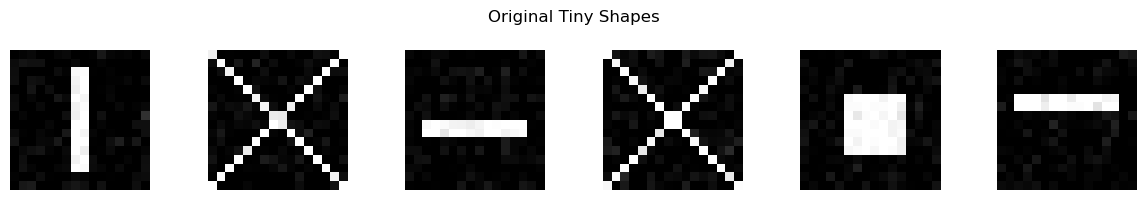

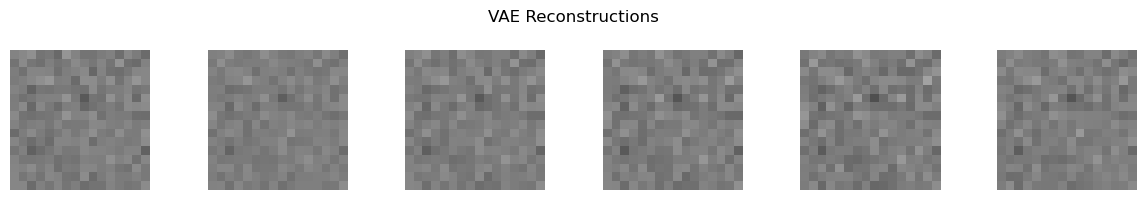

Prefix:    [1, 2, 3]
Generated: [[1, 2, 3, 4, 5, 6, 7]]
Diffusion demo loss: 0.9974


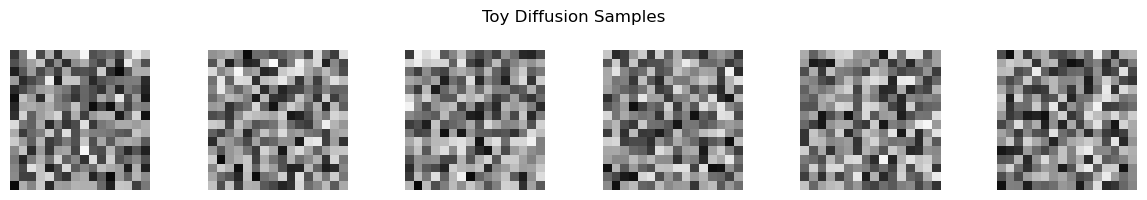

In [16]:
# --- VAE demo ---
train_x = generate_tiny_shape_dataset(n_samples=128, flatten=True, seed=123)
vae = TinyVAE(input_dim=256, hidden_dim=64, latent_dim=8)
vae_opt = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(5):
    vae_opt.zero_grad()
    recon_x, mu, logvar = vae(train_x)
    loss = vae_loss(train_x, recon_x, mu, logvar, beta=0.5)
    loss.backward()
    vae_opt.step()

print(f"VAE demo loss: {loss.item():.4f}")
plot_flattened_images(train_x[:6], title="Original Tiny Shapes")
plot_flattened_images(recon_x[:6], title="VAE Reconstructions")

# --- Toy LM demo ---
lm_data = generate_toy_language_data(n_samples=64, seq_len=8, vocab_size=10, seed=321)
lm = TinyTransformerLM(vocab_size=10, d_model=24, num_heads=4, num_layers=1, max_seq_len=12)
lm_opt = optim.Adam(lm.parameters(), lr=5e-3)

for step in range(30):
    lm_opt.zero_grad()
    logits = lm(lm_data)
    loss_lm = language_model_loss(logits, lm_data)
    loss_lm.backward()
    lm_opt.step()

prefix = lm_data[0, :3]
generated = generate_greedy(lm, prefix, max_new_tokens=4)
print("Prefix:   ", prefix.tolist())
print("Generated:", generated.tolist())

# --- Diffusion demo ---
betas = linear_beta_schedule(20)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
diff_x = generate_tiny_shape_dataset(n_samples=64, flatten=True, seed=456)
denoiser = TinyDenoiser(data_dim=256, hidden_dim=64, time_embed_dim=16, max_timesteps=20)
diff_opt = optim.Adam(denoiser.parameters(), lr=1e-3)

for step in range(40):
    t = torch.randint(0, 20, (diff_x.size(0),))
    noise = torch.randn_like(diff_x)
    diff_opt.zero_grad()
    loss_diff = diffusion_loss(denoiser, diff_x, t, noise, alpha_bars)
    loss_diff.backward()
    diff_opt.step()

samples = sample_diffusion(denoiser, num_samples=6, shape=(256,), betas=betas, alphas=alphas, alpha_bars=alpha_bars)
samples = torch.sigmoid(samples)
print(f"Diffusion demo loss: {loss_diff.item():.4f}")
plot_flattened_images(samples[:6], title="Toy Diffusion Samples")

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)